In [1]:
import subprocess, sys

for pkg in [
    ["torch==2.1.2", "torchvision==0.16.2", "--index-url", "https://download.pytorch.org/whl/cu118"],
    ["diffusers==0.31.0"],
    ["transformers==4.40.0"],
    ["accelerate==0.30.0"],
    ["numpy<2.0"],
    ["Pillow"]
]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkg)

In [2]:
import torch
from diffusers import StableDiffusionPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    safety_checker=None,
    requires_safety_checker=False
).to(device)

/home/s/miniconda3/envs/sd-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  5.62it/s]


  0%|          | 0/20 [00:00<?, ?it/s]/home/s/miniconda3/envs/sd-env/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,
100%|██████████| 20/20 [00:02<00:00,  6.74it/s]


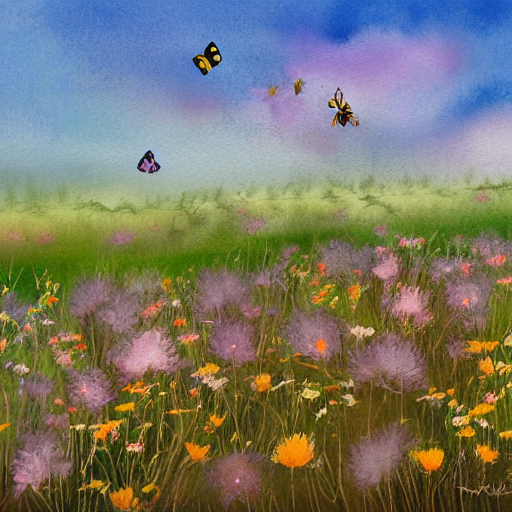

In [ ]:
prompt = (
    "A sunlit meadow filled with blooming wildflowers in pastel colors, "
    "butterflies and bees hovering gently, soft watercolor painting style, "
    "warm afternoon light, peaceful and dreamy atmosphere"
)

image = pipe(
    prompt,
    num_inference_steps=20,
    guidance_scale=7.0
).images[0]

image.save("m_sd_meadow.png")
image